<a href="https://colab.research.google.com/github/Carinaaa/ML-Learning-Path/blob/intro-sklearn/Decision_trees_random_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Gini impurity:**
* listen: https://www.youtube.com/watch?v=_L39rN6gz7Y&list=PLakf6XoaFMqKLBIkOTGxUgABAeNPmbv9g&index=1
* read: https://insidelearningmachines.com/gini_impurity/#:~:text=The%20Gini%20Impurity%20is%20a,typically%20used%20within%20Decision%20Trees.

**Implement DT CART in python:**

* read: https://insidelearningmachines.com/build-a-decision-tree-in-python/
* listen: https://www.youtube.com/playlist?list=PLFrOlc-77-LCDe3vafpNQZCdQUTd9YY6M


In [ ]:
from typing import Tuple

In [ ]:
from __future__ import annotations
from typing import Tuple

class Node(object):
  def __init__(self) -> None:
    self._split = None
    self._feature = None
    self._left = None
    self._right = None
    self.leaf_value = None

  def set_params(self, split: float, feature: int) -> None:
    self._split = split
    self._feature = feature

  def get_params(self) -> Tuple[float,int]:
    return(self._split, self._feature)

  def set_children(self, left: Node, right: Node) -> None:
    self._left = left
    self._right = right

  def get_left_node(self) -> Node:
    return self._left

  def get_right_node(self) -> Node:
    return self._right

In [ ]:
from abc import ABC,abstractmethod
import numpy as np

class DecisionTree(ABC):
  def __init__(self,max_depth: int=None, min_sample_split: int=2) -> None:
    self.tree = None
    self.max_depth = max_depth
    self.min_sample_split = min_sample_split

  @abstractmethod
  def _impurity(self, D: np.array) -> None:
      pass

  @abstractmethod
  def _leaf_value(self, D: np.array) -> None:
     pass

  def _grow(self, node: Node, D: np.array, level: int) -> None:
    # check if leaf node
    depth = (self.max_depth is None) or (self.max_depth >= (level+1))
    msamp = (self.min_samples_split <= D.shape[0])
    n_cls = np.unique(D[:,-1]).shape[0] != 1 # D[:,-1] means everything except last column

    # not a leaf node
    if depth and msamp and n_cls:
      # initialize the function parameters
      ip_node = None
      feature = None
      split   = None
      left_D  = None
      right_D = None
      # iterate through the possible feature/split combinations
      for f in range(D.shape[1]-1):
        for s in np.unique(D[:,f]):
            # for the current (f,s) combination, split the dataset
            D_l = D[D[:,f]<=s]
            D_r = D[D[:,f]>s]
            # ensure we have non-empty arrays
            if D_l.size and D_r.size:
                # calculate the impurity
                ip  = (D_l.shape[0]/D.shape[0])*self._impurity(D_l) + (D_r.shape[0]/D.shape[0])*self._impurity(D_r)
                # now update the impurity and choice of (f,s)
                if (ip_node is None) or (ip < ip_node):
                    ip_node = ip
                    feature = f
                    split   = s
                    left_D  = D_l
                    right_D = D_r

      # set the current node's parameters
      node.set_params(split,feature)
      # declare child nodes
      left_node  = Node()
      right_node = Node()
      node.set_children(left_node,right_node)
      # investigate child nodes
      self.__grow(node.get_left_node(),left_D,level+1)
      self.__grow(node.get_right_node(),right_D,level+1)

    # is a leaf node
    else:
        # set the node value & return
        node.leaf_value = self._leaf_value(D)
        return

  def __traverse(self, node: Node, Xrow: np.array) -> int | float:
        # check if we're in a leaf node?
        if node.leaf_value is None:
            # get parameters at the node
            (s,f) = node.get_params()
            # decide to go left or right?
            if (Xrow[f] <= s):
                return(self.__traverse(node.get_left_node(),Xrow))
            else:
                return(self.__traverse(node.get_right_node(),Xrow))
        else:
            # return the leaf value
            return(node.leaf_value)

  def train(self, Xin: np.array, Yin: np.array) -> None:
        """
        Train the CART model

        Inputs:
            Xin -> input set of predictor features
            Yin -> input set of labels
        """
        # prepare the input data
        D = np.concatenate((Xin,Yin.reshape(-1,1)),axis=1)
        # set the root node of the tree
        self.tree = Node()
        # build the tree
        self.__grow(self.tree,D,1)

  def predict(self, Xin: np.array) -> np.array:
      """
      Make predictions from the trained CART model

      Input:
          Xin -> input set of predictor features
      Output:
          array of prediction values
      """
      # iterate through the rows of Xin
      p = []
      for r in range(Xin.shape[0]):
          p.append(self.__traverse(self.tree,Xin[r,:]))
      # return predictions
      return(np.array(p).flatten())


In [ ]:
class DecisionTreeClassifier(DecisionTree):
    """
    Decision Tree Classifier
    """

    def __init__(self, max_depth: int=None, min_samples_split: int=2, loss: str='gini') -> None:
        """
        Initializer

        Inputs:
            max_depth         -> maximum depth the tree can grow
            min_samples_split -> minimum number of samples required to split a node
            loss              -> loss function to use during training
        """
        DecisionTree.__init__(self,max_depth,min_samples_split)
        self.loss = loss

    def __gini(self, D: np.array) -> float:
        """
        Private function to define the gini impurity

        Input:
            D -> data to compute the gini impurity over
        Output:
            Gini impurity for D
        """
        # initialize the output
        G = 0
        # iterate through the unique classes
        for c in np.unique(D[:,-1]):
            # compute p for the current c
            p = D[D[:,-1]==c].shape[0]/D.shape[0]
            # compute term for the current c
            G += p*(1-p)
        # return gini impurity
        return(G)

    def __entropy(self, D: np.array) -> float:
        """
        Private function to define the shannon entropy

        Input:
            D -> data to compute the shannon entropy over
        Output:
            Shannon entropy for D
        """
        # initialize the output
        H = 0
        # iterate through the unique classes
        for c in np.unique(D[:,-1]):
            # compute p for the current c
            p = D[D[:,-1]==c].shape[0]/D.shape[0]
            # compute term for the current c
            H -= p*np.log2(p)
        # return entropy
        return(H)

    def _impurity(self, D: np.array) -> float:
        """
        Protected function to define the impurity

        Input:
            D -> data to compute the impurity metric over
        Output:
            Impurity metric for D
        """
        # use the selected loss function to calculate the node impurity
        ip = None
        if self.loss == 'gini':
            ip = self.__gini(D)
        elif self.loss == 'entropy':
            ip = self.__entropy(D)
        # return results
        return(ip)

    def _leaf_value(self, D: np.array) -> int:
        """
        Protected function to compute the value at a leaf node

        Input:
            D -> data to compute the leaf value
        Output:
            Mode of D
        """
        return(stats.mode(D[:,-1],keepdims=False)[0])

In [ ]:
all_items = [(22,19), (10,9), (9,9), (7,6)]
new_items = []
for i in all_items:
  ratio = i[1] / i[0]
  new_items.append(i + (ratio,))
print(new_items)

[(22, 19, 0.8636363636363636), (10, 9, 0.9), (9, 9, 1.0), (7, 6, 0.8571428571428571)]


In [ ]:
capacity = 25
gained_capaciy = 0
gained_value = 0
sorted_items = sorted(new_items, key=lambda item: item[2])

while gained_capaciy < capacity and len(sorted_items) > 0:
  if gained_capaciy + sorted_items[-1][0] > capacity:
    #break;
    gained_value += (capacity - gained_capaciy) * sorted_items[-1][2]
    gained_capaciy = capacity
  else:
    gained_capaciy += sorted_items[-1][0]
    gained_value += sorted_items[-1][1]
    sorted_items.pop()

print(gained_value)
print(gained_capaciy)

23.18181818181818
25


In [ ]:
import numpy as np
arr = np.array([
    [1, 2, 3, 4],
    [5, 6, 7, 8],
    [9, 2, 3, 4]
    ])
for f in range(arr.shape[1]-1):
  print(f" f in range: {f}")
  for s in np.unique(arr[:,f]):
    print(f" s: {s}")
    # for the current (f,s) combination, split the dataset
    D_l = arr[arr[:,f]<=s]
    D_r = arr[arr[:,f]>s]
  #print(f"D_l: {D_l}")
  #print(f"D_r: {D_r}")
    # ensure we have non-empty arrays
    if D_l.size and D_r.size:
        # calculate the impurity
        ip  = (D_l.shape[0]/arr.shape[0])*self._impurity(D_l) + (D_r.shape[0]/arr.shape[0])*self._impurity(D_r)
        # now update the impurity and choice of (f,s)
        if (ip_node is None) or (ip < ip_node):
            ip_node = ip
            feature = f
            split   = s
            left_D  = D_l
            right_D = D_r


 f in range: 0
 s: 1
 s: 5
 s: 9
D_l: [[1 2 3 4]
 [5 6 7 8]
 [9 2 3 4]]
D_r: []
 f in range: 1
 s: 2
 s: 6
D_l: [[1 2 3 4]
 [5 6 7 8]
 [9 2 3 4]]
D_r: []
 f in range: 2
 s: 3
 s: 7
D_l: [[1 2 3 4]
 [5 6 7 8]
 [9 2 3 4]]
D_r: []


In [ ]:
    def __gini(self, D: np.array) -> float:
        """
        Private function to define the gini impurity

        Input:
            D -> data to compute the gini impurity over
        Output:
            Gini impurity for D
        """
        # initialize the output
        G = 0
        # iterate through the unique classes
        for c in np.unique(D[:,-1]):
            # compute p for the current c
            p = D[D[:,-1]==c].shape[0]/D.shape[0]
            # compute term for the current c
            G += p*(1-p)
        # return gini impurity
        return(G)

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.Graph() # simple undirected graph
G = nx.DiGraph() # directed graph
G = nx.MultiGraph() # multigraph -> can have multiple edges between nodes
G = nx.MultiDiGraph() # multidigraph directed

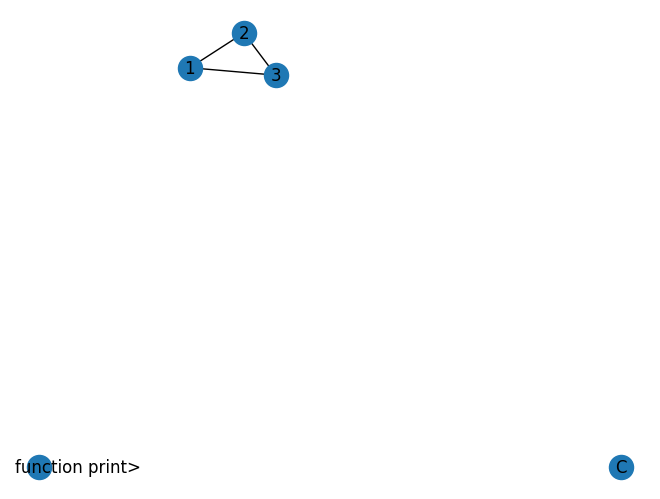

In [ ]:
G = nx.Graph()
G.add_edge(1,2) # the nodes will get created by adding edges
G.add_edge(2,3)
G.add_edge(3,1, weight=0.9)
G.add_node("C")
G.add_node(print) # passing also a function

nx.draw_spring(G, with_labels=True)
plt.show()



<Compressed Sparse Row sparse array of dtype 'int64'
	with 6 stored elements and shape (3, 3)>
  Coords	Values
  (0, 1)	1
  (0, 2)	1
  (1, 0)	1
  (1, 2)	1
  (2, 0)	1
  (2, 1)	1


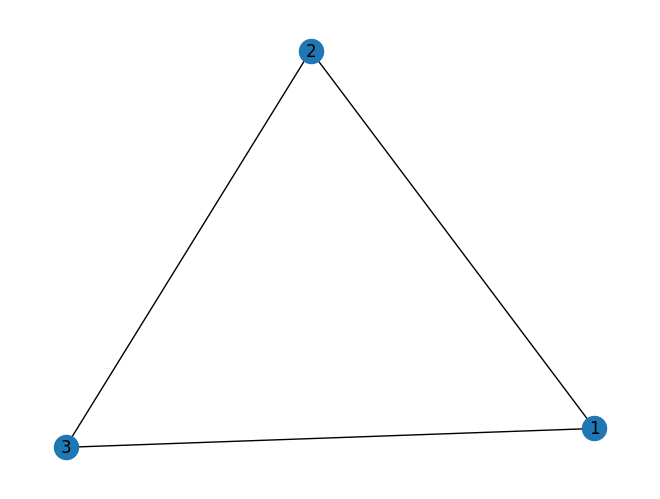

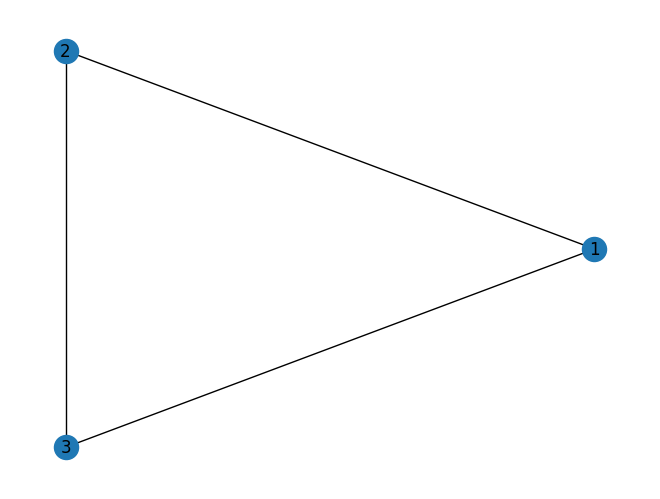

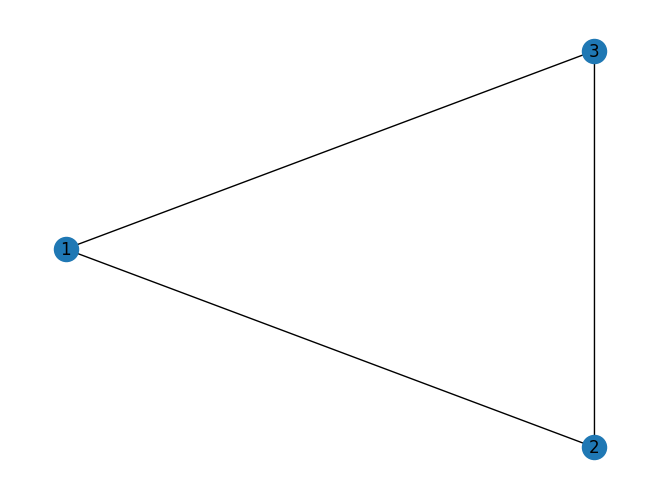

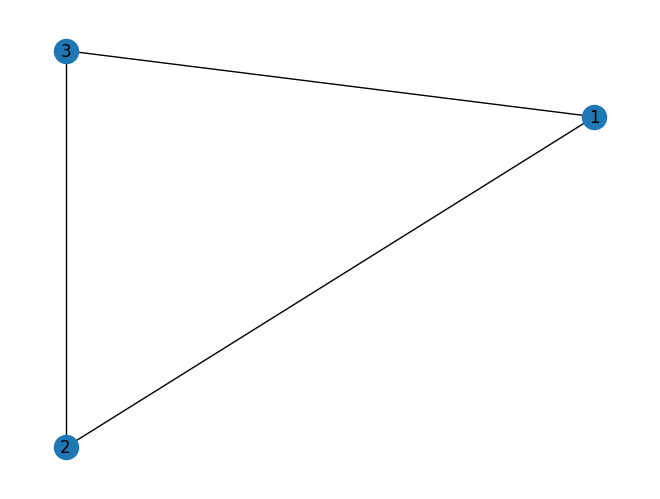

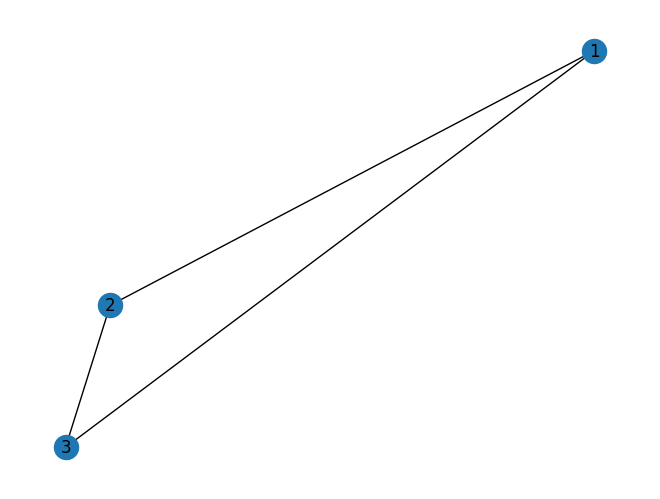

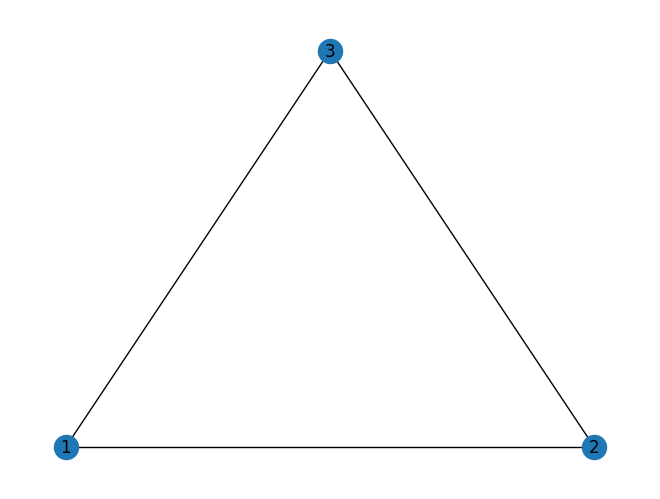

In [ ]:
edge_list = [(1,2),(2,3),(3,1)]
G = nx.Graph()
G.add_edges_from(edge_list)

print(nx.adjacency_matrix(G))

nx.draw_spring(G, with_labels=True)
plt.show()

nx.draw_circular(G, with_labels=True)
plt.show()

nx.draw_shell(G, with_labels=True)
plt.show()

nx.draw_spectral(G, with_labels=True)
plt.show()

nx.draw_random(G, with_labels=True)
plt.show()

nx.draw_planar(G, with_labels=True) # no edges intersections
plt.show()

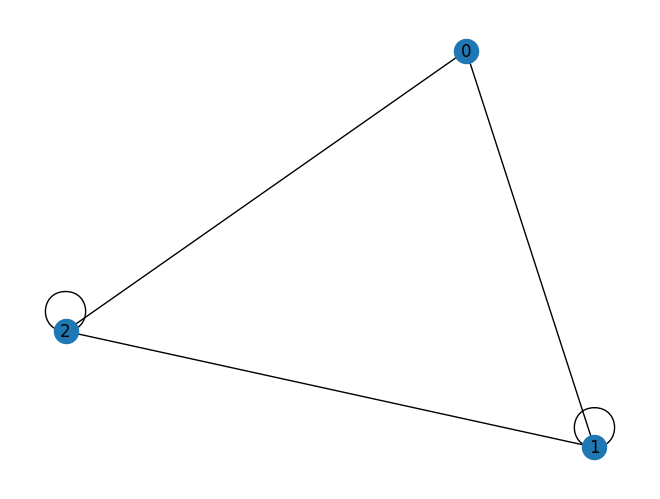

In [ ]:
import numpy as np
B = np.array([[0,1,0],
         [1,1,1],
         [1,0,1]])

G1 = nx.from_numpy_array(B)

nx.draw_spring(G1, with_labels=True)
plt.show()

1


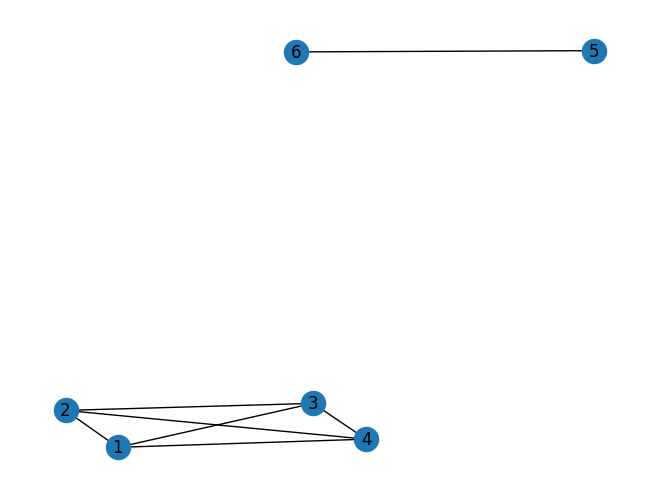

In [ ]:
edge_list = [(1,2),(1,3), (1,4), (2,3), (2,4), (3,4), (5,6)]
g = nx.from_edgelist(edge_list)

print(dict(g.degree)[6]) # the number of edges connected to that node.

nx.draw_spring(g, with_labels=True)
plt.show()

1
2


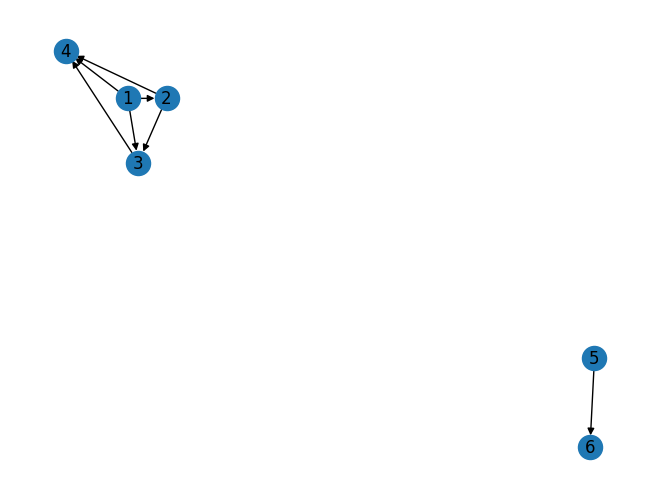

In [ ]:
edge_list = [(1,2),(1,3), (1,4), (2,3), (2,4), (3,4), (5,6)]
g_d = nx.DiGraph()
g_d.add_edges_from(edge_list)

print(dict(g_d.in_degree)[6]) # the number of edges connected to that node.
print(dict(g_d.out_degree)[2])

nx.draw_spring(g_d, with_labels=True)
plt.show()

[1, 2, 8, 9]
3


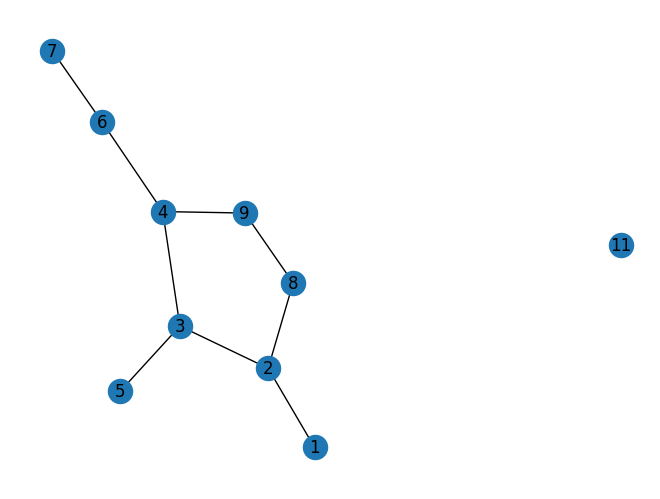

In [ ]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7),(2,8),(8,9),(9,4)]

g = nx.Graph()
g.add_edges_from(edge_list)
g.add_node(11,UTM=("test", 23)) # ?????

print(nx.shortest_path(g,1,9))
print(nx.shortest_path_length(g,1,9))

nx.draw_spring(g, with_labels=True)
plt.show()

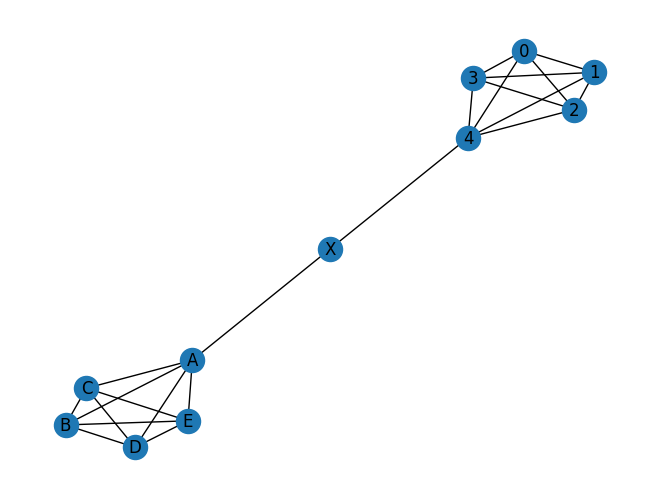

[(4, 0), (0, 1), (1, 2), (2, 0), (0, 3), (3, 1), (1, 4), (4, 2), (2, 3), (3, 4), (4, 'X'), ('X', 'A'), ('A', 'B'), ('B', 'C'), ('C', 'A'), ('A', 'D'), ('D', 'B'), ('B', 'E'), ('E', 'C'), ('C', 'D'), ('D', 'E'), ('E', 'A')]


In [ ]:
G1 = nx.complete_graph(5)
G2 = nx.complete_graph(5)
G2 = nx.relabel_nodes(G2, {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'})
G_connector = nx.from_edgelist([(4, "X"), ("X",'A')])

G = nx.compose_all([G1, G2, G_connector])

nx.draw_spring(G, with_labels=True)
plt.show()

print(list(nx.eulerian_path(G)))

red


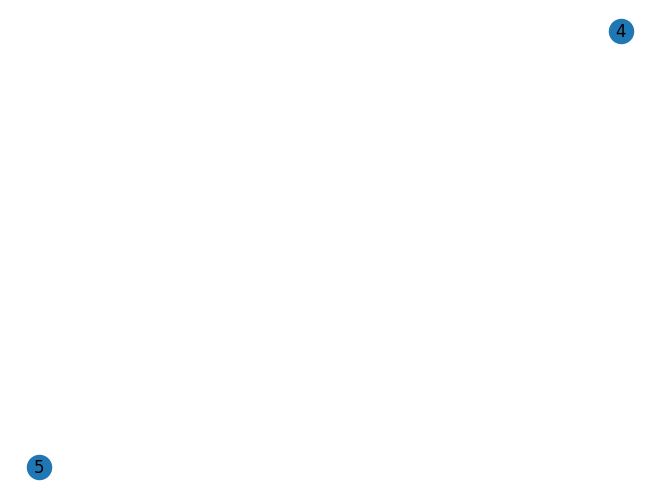

In [ ]:
B = nx.Graph()
B.add_nodes_from([(4, {"color": "red"}), (5, {"color": "green"})])
print(B.nodes[4]['color'])
nx.draw_random(B, with_labels=True)
plt.show()

[[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 0 1 1]
 [1 1 1 1 0]]
features: 0
split: 0
data_left: [[0 1 1 0 0]
 [0 1 0 1 1]]
data_right: [[1 1 1 0 0]
 [1 1 0 0 1]
 [1 1 1 1 0]]
ip: 0.4666666666666667
split: 1
data_left: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 0 1 1]
 [1 1 1 1 0]]
data_right: []
features: 1
split: 1
data_left: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 0 1 1]
 [1 1 1 1 0]]
data_right: []
features: 2
split: 0
data_left: [[1 1 0 0 1]
 [0 1 0 1 1]]
data_right: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 1 1 0]]
ip: 0.0
split: 1
data_left: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 0 1 1]
 [1 1 1 1 0]]
data_right: []
features: 3
split: 0
data_left: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]]
data_right: [[0 1 0 1 1]
 [1 1 1 1 0]]
ip: 0.4666666666666667
split: 1
data_left: [[0 1 1 0 0]
 [1 1 1 0 0]
 [1 1 0 0 1]
 [0 1 0 1 1]
 [1 1 1 1 0]]
data_right: []


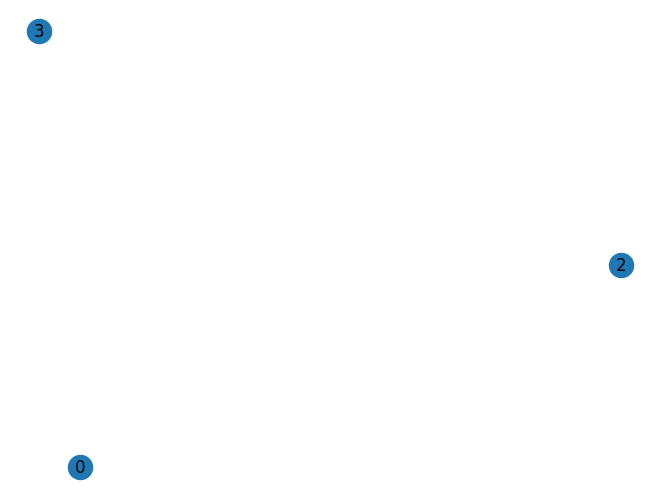

In [ ]:
import random
import numpy as np
import networkx as nx

FEATURES_NUMBER = 5
DATA_ENTRIES = 5

dec_tree = nx.Graph()

random.seed(10)
# Initialize data as an empty NumPy array with the desired number of columns
data = np.empty((0, FEATURES_NUMBER), int) # Assuming 2 columns based on your entry generation

for _ in range(DATA_ENTRIES):
  entry = np.array([random.randint(0,1) for _ in range(FEATURES_NUMBER)])
  # Vertically stack the new entry onto the data array
  data = np.vstack((data, entry))
print(data)

def impurity(D : np.array):
  G = 0
  for c in np.unique(D[:,-1]):
    probability = D[D[:,-1]==c].shape[0]/D.shape[0]
    G += probability*(1-probability)
  return G

for f in range(data.shape[1]-1):
  print(f"features: {f}")
  for s in np.unique(data[:,f]):
    print(f"split: {s}")
    # divide the dataset based on split, some of them will go to the left, other to the right
    data_left = data[data[:,f]<=s]
    data_right = data[data[:,f]>s]
    print(f"data_left: {data_left}")
    print(f"data_right: {data_right}")
    if data_left.size and data_right.size:
      ip = (data_left.shape[0]/data.shape[0])*impurity(data_left) + (data_right.shape[0]/data.shape[0])*impurity(data_right)
      dec_tree.add_node(f,feat=f,split=s,ip=ip)
      print(f"ip: {ip}")

nx.draw_spring(dec_tree, with_labels=True)
plt.show()

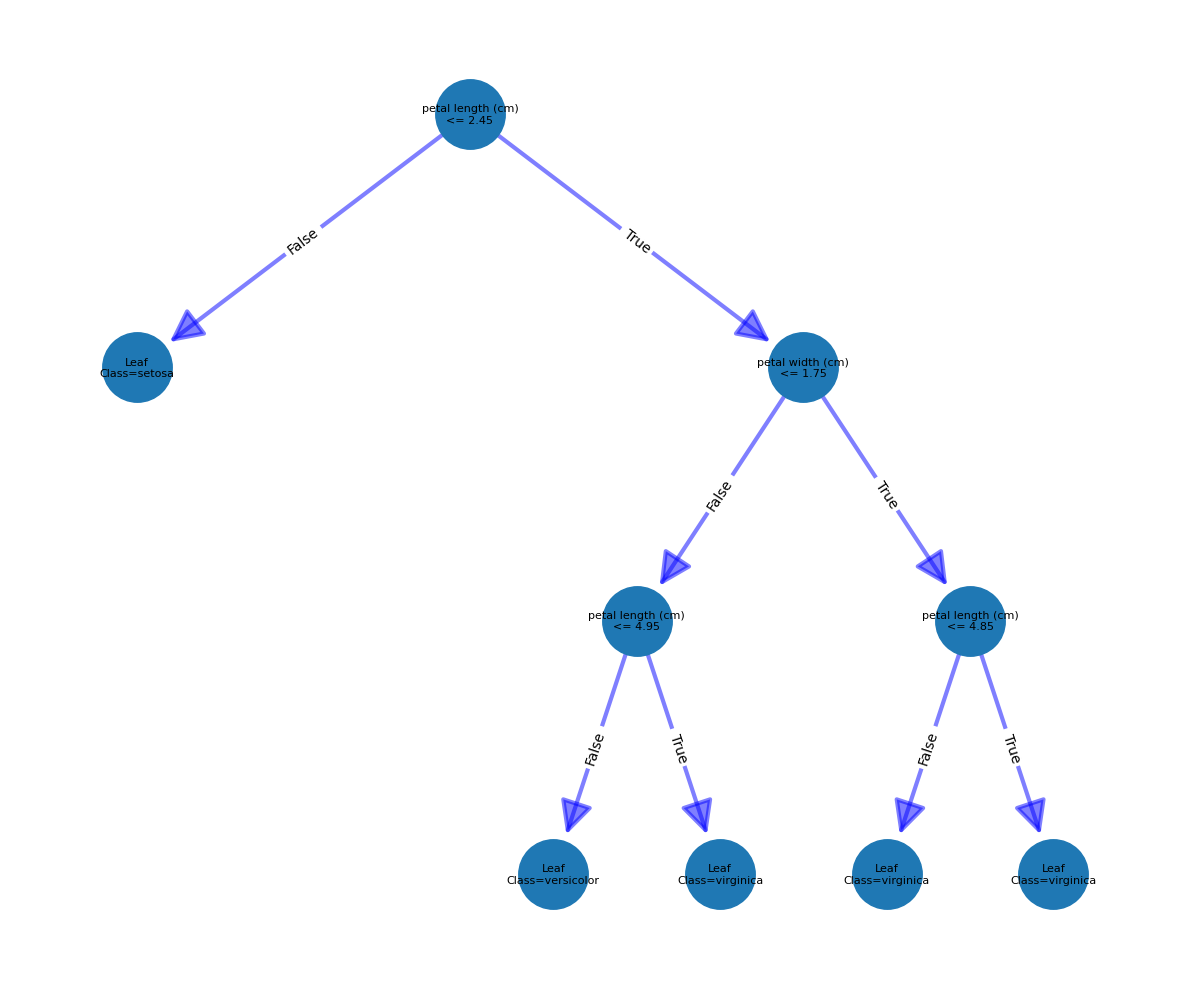

In [ ]:
# file: cart_networkx_example.py
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

def hierarchy_pos(G, root=0, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5):
    """
    Compute positions for nodes in a binary (or general) tree layout.
    Adapted for hierarchical visualization.
    """
    pos = {root: (xcenter, vert_loc)}
    children = list(G.successors(root))
    if len(children) != 0:
        dx = width / len(children)
        nextx = xcenter - width / 2 - dx / 2
        for child in children:
            nextx += dx
            pos.update(hierarchy_pos(G, child, width=dx, vert_gap=vert_gap,
                                     vert_loc=vert_loc - vert_gap, xcenter=nextx))
    return pos

# --- Step 1: Load data ---
X, y = load_iris(return_X_y=True)

# --- Step 2: Train CART model ---
clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42,
    min_samples_split=2
)
clf.fit(X, y)

# --- Step 3: Extract tree structure ---
tree = clf.tree_
feature_names = load_iris().feature_names

# --- Step 4: Build NetworkX graph ---
G = nx.DiGraph()

def add_nodes_edges(node_id=0, parent=None, weight=False):
    """Recursively add nodes/edges from sklearn tree_"""
    classes = np.array(['setosa', 'versicolor', 'virginica'])
    if node_id == -1:
        return

    # Label node
    if tree.children_left[node_id] == tree.children_right[node_id]:
        label = f"Leaf\nClass={classes[tree.value[node_id].argmax()]}"
    else:
        feat = feature_names[tree.feature[node_id]]
        thresh = tree.threshold[node_id]
        label = f"{feat}\n<= {thresh:.2f}"

    G.add_node(node_id, label=label)

    # connect to parent
    if parent is not None:
      G.add_edge(parent, node_id, weight = weight)

    # recurse children
    left, right = tree.children_left[node_id], tree.children_right[node_id]
    if left != -1:
        add_nodes_edges(left, node_id, False)
    if right != -1:
        add_nodes_edges(right, node_id, True)

add_nodes_edges()

# --- Step 5: Visualize ---
labels = nx.get_node_attributes(G, "label")

plt.figure(figsize=(12, 10))

# Get hierarchical layout
pos = hierarchy_pos(G, root=0)

# nodes
nx.draw_networkx_nodes(G, pos, node_size=2500)

# edges
nx.draw_networkx_edges(
    G,
    pos,
    width=3,
    alpha=0.5,
    edge_color="b",
    arrowstyle='-|>',
    arrowsize=50,
    min_source_margin = 20,
    min_target_margin = 30
)

# node labels
nx.draw_networkx_labels(G, pos, font_size=8, font_family="sans-serif",
    labels=labels)

# edge weight labels
edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels)

ax = plt.gca()
ax.margins(0.08)
plt.axis("off")
plt.tight_layout()
plt.show()

## Metrics differences on iris data

link: https://scikit-learn.org/stable/api/sklearn.metrics.html

* The precision is the ratio tp / (tp + fp) where tp is the number of true positives and fp the number of false positives.
The precision is intuitively the ability of the classifier not to label as positive a sample that is negative.

* The recall is the ratio tp / (tp + fn) where tp is the number of true positives and fn the number of false negatives. The recall is intuitively the ability of the classifier to find all the positive samples.

* f1_score - https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html#sklearn.metrics.f1_score

* accuracy_score is a metric that it is the same as the model.score() function.








In [ ]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


clf_decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42,
    min_samples_split=2
)
clf_decision_tree.fit(X_train, y_train)
y_pred = clf_decision_tree.predict(X_test)

print(f"score() : {clf_decision_tree.score(X_test, y_test)}")

print(f"precision_score() : {precision_score(y_test, y_pred, average=None)}")
print(f"recall_score() : {recall_score(y_test, y_pred, average=None)}")
print(f"f1_score() : {f1_score(y_test, y_pred, average=None)}")
print(f"accuracy_score() : {accuracy_score(y_test, y_pred)}")


clf_extra_tree = ExtraTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42,
    min_samples_split=2
)
clf_extra_tree.fit(X_train, y_train)
y_pred = clf_extra_tree.predict(X_test)

print("\n\nChanged to Extra Decision Tree: \n")

print(f"score() : {clf_extra_tree.score(X_test, y_test)}")

print(f"precision_score() : {precision_score(y_test, y_pred, average=None)}")
print(f"recall_score() : {recall_score(y_test, y_pred, average=None)}")
print(f"f1_score() : {f1_score(y_test, y_pred, average=None)}")
print(f"accuracy_score() : {accuracy_score(y_test, y_pred)}")

score() : 0.9666666666666667
precision_score() : [1.         0.88888889 1.        ]
recall_score() : [1.         1.         0.90909091]
f1_score() : [1.         0.94117647 0.95238095]
accuracy_score() : 0.9666666666666667


Changed to Extra Decision Tree: 

score() : 0.9333333333333333
precision_score() : [1.         1.         0.84615385]
recall_score() : [1.   0.75 1.  ]
f1_score() : [1.         0.85714286 0.91666667]
accuracy_score() : 0.9333333333333333


While 'gini', 'entropy', and 'log_loss' are different mathematical formulas for calculating impurity, they all aim to find splits that maximize information gain or minimize impurity. In some cases, especially with smaller or simpler datasets, different impurity measures can lead to the same optimal splits at each node, resulting in identical tree structures and performance metrics.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, ExtraTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


clf_decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3, # This limits how deep the tree can grow. A shallower tree might underfit, while a very deep tree might overfit. Changing this will likely change the splits and leaf nodes.
    random_state=42, # This affects the random splitting of data when max_features is less than the total number of features. While not directly changing the split criterion, it can influence which features are considered at each node, potentially leading to a different tree.
    min_samples_split=2 # This sets the minimum number of samples required to split an internal node. Increasing this value will result in a smaller tree with fewer splits.
)
clf_decision_tree.fit(X_train, y_train)
y_pred = clf_decision_tree.predict(X_test)

print("GINI\n")

print(f"score() : {clf_decision_tree.score(X_test, y_test)}")

print(f"precision_score() : {precision_score(y_test, y_pred, average=None)}")
print(f"recall_score() : {recall_score(y_test, y_pred, average=None)}")
print(f"f1_score() : {f1_score(y_test, y_pred, average=None)}")
print(f"accuracy_score() : {accuracy_score(y_test, y_pred)}")

clf_decision_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42,
    min_samples_split=2
)
clf_decision_tree.fit(X_train, y_train)
y_pred = clf_decision_tree.predict(X_test)

print("\n\nENTROPY\n")

print(f"score() : {clf_decision_tree.score(X_test, y_test)}")

print(f"precision_score() : {precision_score(y_test, y_pred, average=None)}")
print(f"recall_score() : {recall_score(y_test, y_pred, average=None)}")
print(f"f1_score() : {f1_score(y_test, y_pred, average=None)}")
print(f"accuracy_score() : {accuracy_score(y_test, y_pred)}")

clf_decision_tree = DecisionTreeClassifier(
    criterion="log_loss",
    max_depth=3,
    random_state=42,
    min_samples_split=2
)
clf_decision_tree.fit(X_train, y_train)
y_pred = clf_decision_tree.predict(X_test)

print("\n\nLOG LOSS\n")

print(f"score() : {clf_decision_tree.score(X_test, y_test)}")

print(f"precision_score() : {precision_score(y_test, y_pred, average=None)}")
print(f"recall_score() : {recall_score(y_test, y_pred, average=None)}")
print(f"f1_score() : {f1_score(y_test, y_pred, average=None)}")
print(f"accuracy_score() : {accuracy_score(y_test, y_pred)}")

GINI

score() : 0.9333333333333333
precision_score() : [1.         1.         0.81818182]
recall_score() : [1.         0.71428571 1.        ]
f1_score() : [1.         0.83333333 0.9       ]
accuracy_score() : 0.9333333333333333


ENTROPY

score() : 0.9333333333333333
precision_score() : [1.         1.         0.81818182]
recall_score() : [1.         0.71428571 1.        ]
f1_score() : [1.         0.83333333 0.9       ]
accuracy_score() : 0.9333333333333333


LOG LOSS

score() : 0.9333333333333333
precision_score() : [1.         1.         0.81818182]
recall_score() : [1.         0.71428571 1.        ]
f1_score() : [1.         0.83333333 0.9       ]
accuracy_score() : 0.9333333333333333


#### TODO : plots for the decision trees (classifiers), see metrics above + how to improve scoring techniques
#### TODO : plots for forrest (regression) with different number of estimators
####